# Loan Risk Assessment and Customer Credit Analysis

This Project focuses on analyzing customer financial information to better understand loan related risk and customer credit behaviour. The analysis is based on application income, loan amount , credit related information , and assets details.
The purpose of this project is to study patterns that may influence loan approval decision and support practical banking analysis using data science tecniques.

## Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [4]:
df = pd.read_csv("C:/Users/suman/Downloads/archive/loan_approval_dataset.csv")

## Preview of the dataset

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Dataset Structure and Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Statistical Summary of Numerical Features

In [7]:

df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Data Cleaning and Column Formatting

In [9]:
df.columns = df.columns.str.strip()

## Exploratory Data Analysis

### 1.Distribution of Customer CIBIL Scores

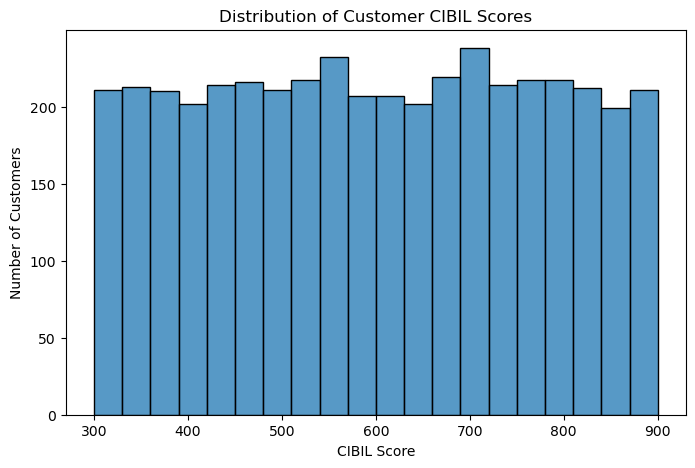

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['cibil_score'], bins=20)
plt.title("Distribution of Customer CIBIL Scores")
plt.xlabel("CIBIL Score")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### 2.Loan Approval Status Analysis

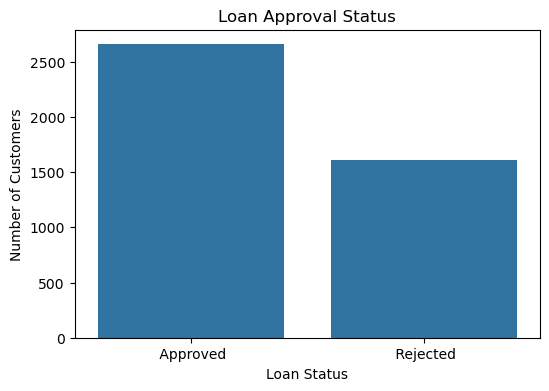

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.show()

### 3.Relationship Between CIBIL Score and Loan Approval

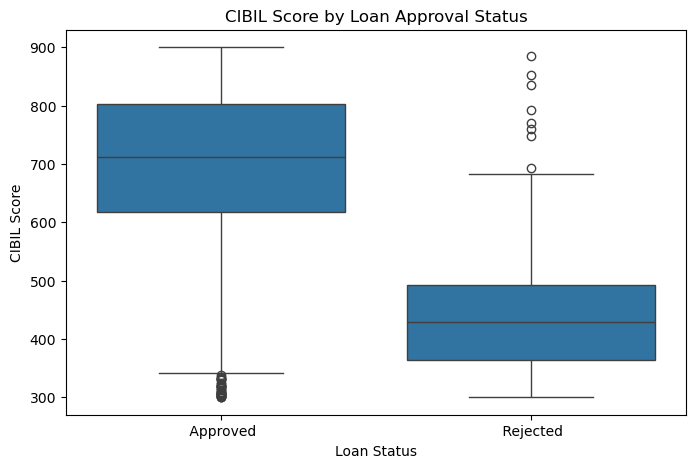

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title("CIBIL Score by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")
plt.show()

### 4. Income Distribution Based on Loan Approval

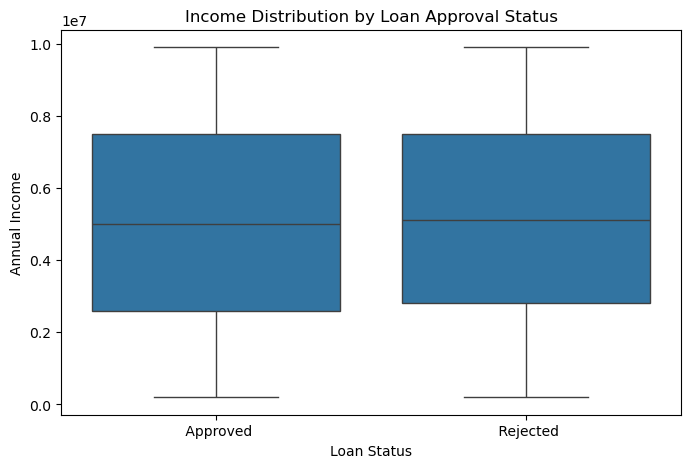

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title("Income Distribution by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

#### 5.Loan Amount Analysis

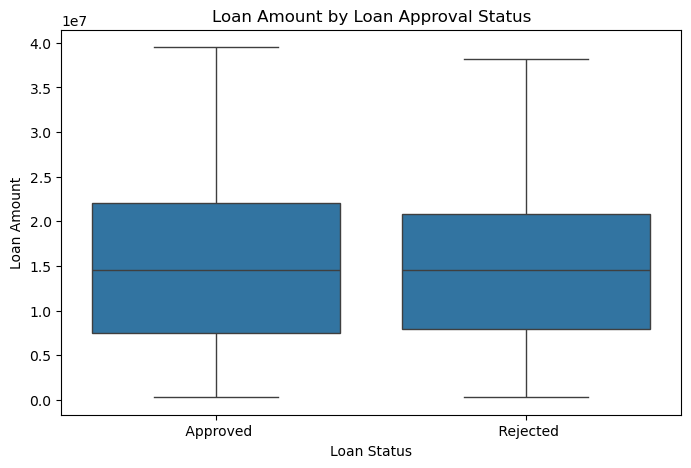

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='loan_amount', data=df)
plt.title("Loan Amount by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

### 6. Relationship Between Incomes and Loan Amount

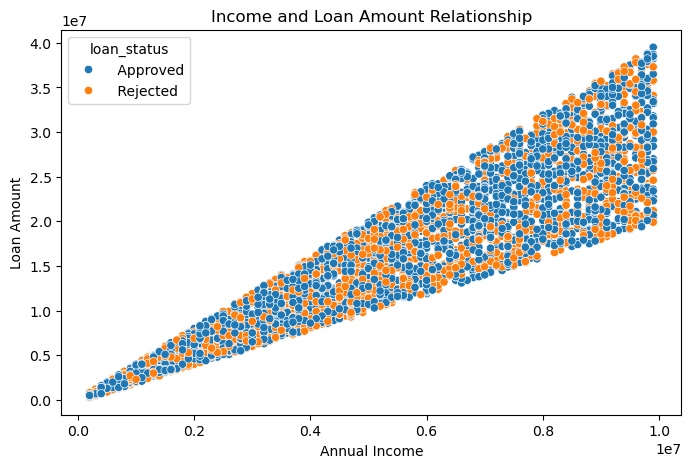

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df)
plt.title("Income and Loan Amount Relationship")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

### 7. Estimated Loan Eligibility Amount

The estimated loan eligibility amount was calculated using customer income, credit score, number of dependents, and total asset value. Customers with stronger financial profiles and higher CIBIL scores generally showed higher estimated loan approval capacity.

#### 7.1 Total Assets Calculation

In [18]:
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['bank_asset_value']
)

#### 7.2 Credit Score 

In [19]:
def credit_score_factor(score):
    if score >= 750:
        return 1.20
    elif score >= 650:
        return 1.00
    elif score >= 550:
        return 0.70
    else:
        return 0.40
df['credit_factor'] = df['cibil_score'].apply(credit_score_factor)

#### 7.3 Dependent Factor

In [20]:
df['dependent_factor'] = 1 - (df['no_of_dependents'] * 0.05)

#### 7.4 Income Based Capacity

In [21]:
df['income_based_capacity'] = (
    df['income_annum'] * 4 * df['credit_factor'] * df['dependent_factor']
)

#### 7.5 Assets Based Capacity

In [22]:
df['asset_based_capacity'] = df['total_assets'] * 0.70

#### 7.6 Final Estimated Capacity

In [23]:
df['estimated_approvable_amount'] = df[
    ['income_based_capacity', 'asset_based_capacity']
].min(axis=1)

#### 7.7 Compare with Requested Loan

In [24]:
df['loan_within_estimated_limit'] = (
    df['loan_amount'] <= df['estimated_approvable_amount']
)

#### 7.8 View Result

In [25]:
df[['income_annum', 'cibil_score', 'no_of_dependents', 'loan_amount',
    'estimated_approvable_amount', 'loan_within_estimated_limit', 'loan_status']].head()

,income_annum,cibil_score,no_of_dependents,loan_amount,estimated_approvable_amount,loan_within_estimated_limit,loan_status
0,9600000,778,2,29900000,19600000.0,False,Approved
1,4100000,417,0,12200000,5740000.0,False,Rejected
2,9100000,506,3,29700000,12376000.0,False,Rejected
3,8200000,467,3,30700000,11152000.0,False,Rejected
4,9800000,382,5,24200000,11760000.0,False,Rejected


## Preparing Data For Machine Learnig

This section prepares the loan dataset for predictive modeling. Machine learning models need numerical inputs, so text-based columns such as education, employment status, and loan status are converted into numeric values.

### 8.1 Checking Categorical Values

In [26]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [27]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [28]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### 8.2 Converting Categorical Variables

In [30]:
df['education'] = df['education'].map({
    ' Graduate': 1,
    ' Not Graduate': 0
})

In [31]:
df['self_employed'] = df['self_employed'].map({
    ' Yes': 1,
    ' No': 0
})

In [32]:
df['loan_status'] = df['loan_status'].map({
    ' Approved': 1,
    ' Rejected': 0
})

### 8.3 Checking Converted Dataset

In [33]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,credit_factor,dependent_factor,income_based_capacity,asset_based_capacity,estimated_approvable_amount,loan_within_estimated_limit
0,1,2,NaN,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,28000000,1.2,0.90,41472000.0,19600000.0,19600000.0,False
1,2,0,NaN,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,8200000,0.4,1.00,6560000.0,5740000.0,5740000.0,False
2,3,3,NaN,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,24400000,0.4,0.85,12376000.0,17080000.0,12376000.0,False
3,4,3,NaN,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,29400000,0.4,0.85,11152000.0,20580000.0,11152000.0,False
4,5,5,NaN,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,25600000,0.4,0.75,11760000.0,17920000.0,11760000.0,False


### 8.4 Feature and Target Selection

In [34]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

### 8.5 Splitting Data into Training and Testing Sets

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
X_train.shape, X_test.shape

((3415, 19), (854, 19))

## 9. Logistic Regression Model


Logistic Regression was used to predict loan approval status using customer financial and credit-related information. The model helps classify whether a loan application is likely to be approved or rejected based on customer income, credit score, loan amount, dependents, and asset values.

### Feature and Target Selection

In [44]:
X = df.drop(['loan_status', 'loan_id'], axis=1)
y = df['loan_status']

### Convert Remaining Text Columns

In [45]:
X = pd.get_dummies(X, drop_first=True)

### Handle Missing Values

In [46]:
X = X.fillna(0)
y = y.fillna(0)

### Split Data into Training and Testing Sets

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Check Training Dataset

In [48]:
X_train.dtypes

no_of_dependents                 int64
education                      float64
self_employed                    int64
income_annum                     int64
loan_amount                      int64
loan_term                        int64
cibil_score                      int64
residential_assets_value         int64
commercial_assets_value          int64
luxury_assets_value              int64
bank_asset_value                 int64
total_assets                     int64
credit_factor                  float64
dependent_factor               float64
income_based_capacity          float64
asset_based_capacity           float64
estimated_approvable_amount    float64
loan_within_estimated_limit       bool
dtype: object

### Import and Run the Model

In [38]:
from sklearn.linear_model import LogisticRegression

### Create the Logistic Regression Model

In [39]:
model = LogisticRegression(max_iter=1000)

### Train the Model

In [62]:
model.fit(X_train, y_train);

### Make Predictions
The trained Logistic Regression model was used to predict loan approval outcomes for the testing dataset. The prediction results help identify whether a loan application is likely to be approved or rejected.

In [50]:
y_pred = model.predict(X_test)

###  View Sample Predictions

In [51]:
print(y_pred[:10])

[0 1 0 1 1 1 1 0 1 0]


### Check Model Accuracy

Model accuracy was calculated to evaluate how well the Logistic Regression model predicts loan approval status using unseen testing data.

In [52]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9344262295081968


### Classification Report

In [53]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       318
           1       0.95      0.95      0.95       536

    accuracy                           0.93       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854



### Check Model Accuracy
Model accuracy was calculated to evaluate how well the Logistic Regression model predicts loan approval status using unseen testing data.

In [54]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[289  29]
 [ 27 509]]


### Confusion Matrix
A confusion matrix was used to compare actual loan approval results with predicted results. This helps evaluate the classification performance of the model.

In [55]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[289  29]
 [ 27 509]]


### Visualizing Confusion Matrix
The confusion matrix was visualized to better understand the prediction performance of the Logistic Regression model.

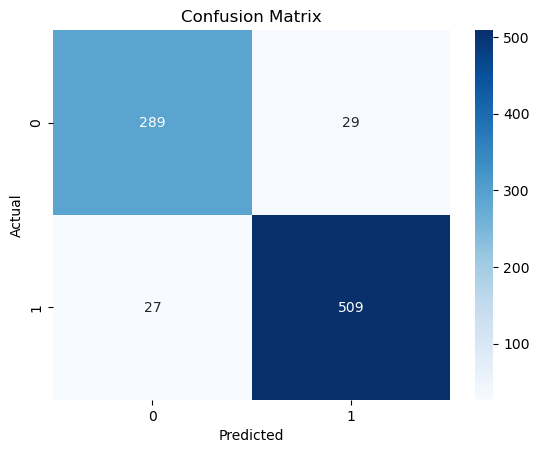

In [56]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10. Feature Importance Analysis

The Logistic Regression coefficients were analyzed to understand which financial and credit-related variables have stronger influence on loan approval prediction.

In [57]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
feature_importance

,Feature,Coefficient
0,no_of_dependents,2.325227e-02
1,education,0.000000e+00
2,self_employed,-1.572085e-03
3,income_annum,-3.865387e-06
4,loan_amount,3.645238e-07
5,loan_term,-2.559325e-01
6,cibil_score,5.305441e-03
7,residential_assets_value,-1.833849e-09
8,commercial_assets_value,1.950301e-08
9,luxury_assets_value,3.200758e-08


### 10.1 Sort Important Features

In [59]:
feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)
feature_importance.head(10)

,Feature,Coefficient
0,no_of_dependents,2.325227e-02
6,cibil_score,5.305441e-03
12,credit_factor,2.600079e-03
17,loan_within_estimated_limit,2.489072e-03
14,income_based_capacity,1.071144e-06
16,estimated_approvable_amount,5.038567e-07
4,loan_amount,3.645238e-07
9,luxury_assets_value,3.200758e-08
8,commercial_assets_value,1.950301e-08
1,education,0.000000e+00


### 10.2 Visualize Important Features

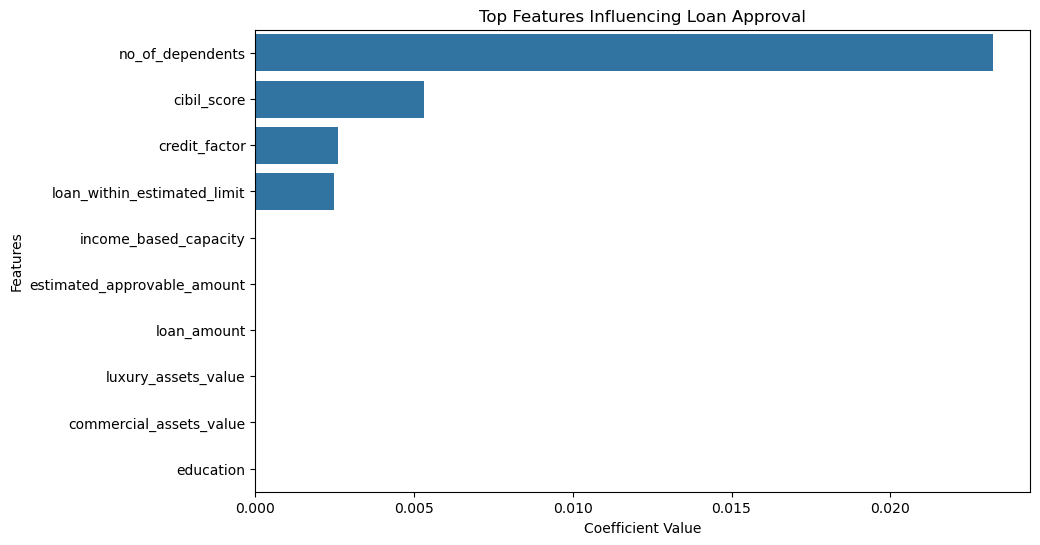

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top Features Influencing Loan Approval")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

## 11. Final Conclusion
This project analyzed customer financial and credit-related information to predict loan approval status using Logistic Regression. The analysis included data exploration, loan eligibility estimation, feature preparation, model training, prediction, and evaluation. The model achieved effective classification performance and demonstrated how customer income, credit score, dependents, and asset values influence loan approval decisions. This project also reflects practical banking-related loan assessment concepts combined with machine learning techniques.